# $DMO_{n} + Fatigue_{n-1} \rightarrow Fatigue_{n}$

In [1]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import DMOLSTM, ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.core.data_transforms import Transform
from src.model import lstm_regression
from src.train import TrainRegression
from src.pipeline.dmo.dmo_into_dataloader import dmo_into_dataloader

import matplotlib.pyplot as plt

import numpy as np
import torch

KeyboardInterrupt: 

In [ ]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=176,
    hidden_size=128,
    num_layers=1,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [ ]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [ ]:
dmo_data.shape

torch.Size([280, 5, 7, 25])

In [ ]:
dmo_labels.shape

torch.Size([280, 5, 1])

In [ ]:
dmo_data_lagged_fatigue = Transform.format_input_data_lag_label(dmo_data, dmo_labels)

In [ ]:
dmo_data_lagged_fatigue.shape

torch.Size([280, 5, 176])

In [ ]:
print(dmo_data_lagged_fatigue[0])
print(dmo_labels[0])

tensor([[2.8200e+02, 6.1000e+01, 4.8180e+03, 8.4000e+00, 2.4800e+01, 1.6000e+02,
         8.4000e+01, 1.3200e+00, 1.3000e+01, 1.8000e+01, 6.6000e-01, 9.8000e+01,
         1.1600e+02, 8.2000e-01, 1.6000e+01, 7.5000e-01, 1.0400e+02, 8.4000e+01,
         1.2800e+00, 1.1900e+00, 9.2000e+01, 4.4000e+01, 3.4000e+01, 2.0000e+00,
         2.4000e+01, 2.6200e+02, 5.4000e+01, 4.4480e+03, 8.4000e+00, 1.8900e+01,
         2.0100e+02, 8.6000e+01, 1.3200e+00, 1.2000e+01, 1.8000e+01, 6.1000e-01,
         8.8000e+01, 1.0300e+02, 7.3000e-01, 7.0000e+00, 1.1300e+00, 1.4300e+02,
         8.9000e+01, 1.1900e+00, 1.8900e+00, 1.0400e+02, 6.2000e+01, 5.0000e+01,
         3.0000e+00, 2.3540e+01, 2.9600e+02, 6.4000e+01, 5.4720e+03, 7.4000e+00,
         1.7700e+01, 2.2900e+02, 8.6000e+01, 1.2900e+00, 1.3000e+01, 2.0000e+01,
         6.2000e-01, 9.1000e+01, 8.6000e+01, 8.7000e-01, 1.0000e+01, 1.3900e+00,
         1.7200e+02, 9.3000e+01, 1.1800e+00, 1.9100e+00, 1.0300e+02, 4.5000e+01,
         3.7000e+01, 6.0000e

In [ ]:
transforms = (None, None)
training_dl, testing_dl = dmo_into_dataloader(dmo_data_lagged_fatigue, dmo_labels, batch_size=16, transforms=transforms)

In [ ]:
model = DMOLSTM(config).to(device=device)
optimiser = config.optimiser(model.parameters(), lr=config.learning_rate)

trainer = TrainRegression(
    model,
    optimiser,
    config,
    training_dl,
    testing_dl,
    device,
    verbose=True,
)


trainer.train_loop()
prediction, actual = trainer.test_loop()

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([16])) that is different to the input size (torch.Size([16, 5, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Testing loss: 0.07496145507320762


/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 5, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [ ]:
actual = torch.stack(actual)
prediction = torch.stack(prediction)


TypeError: stack(): argument 'tensors' (position 1) must be tuple of Tensors, not Tensor

In [ ]:
prediction = prediction.squeeze()

All metrics: {'accuracy': 0.26785714285714285, 'Mean Squared Error': 0.10525163263082504, 'Mean Absolute Error': 0.25833094120025635, 'R^2': -0.974162220954895}


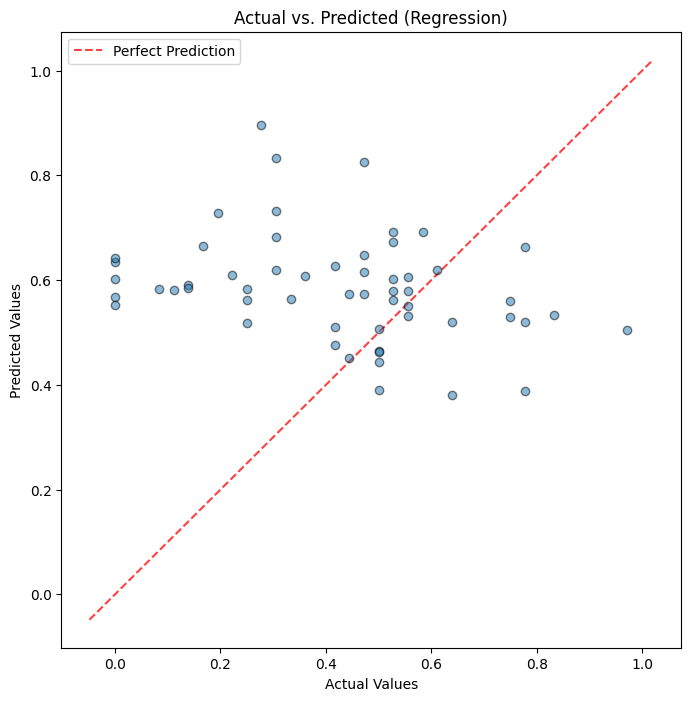

In [ ]:
from src.evaluation import Evaluation

actual_values = torch.Tensor(actual)
predicted_values = torch.Tensor(prediction)

evaluation = Evaluation(predicted_values, actual_values)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
